Implement numerical_second_derivative(f, x) using numerical_derivative called twice. Verify that the second derivative of x^3 at x=2 is 12.

In [8]:
def numerical_derivative(f, x, h=1e-7):
    return (f(x + h) - f(x - h)) / (2 * h)

def f(x):
    return x ** 3

def numerical_second_derivative(f,x,h=1e-7):
    df=lambda t:numerical_derivative(f,t,h)
    return numerical_derivative(df,x,h)

numerical_second_derivative(f,2)

11.923795284474181

Use gradient descent to find the minimum of f(x, y) = (x - 3)^2 + (y + 1)^2. Start from (0, 0). The answer should converge to (3, -1).

In [10]:
import numpy as np

def f(x,y):
    return (x-3)**2 +(y+1)**2

def grad(x,y):
    return 2*(x-3),2*(y+1)

x,y=0,0
lr=0.1

for epoch in range(100):
    dx,dy=grad(x,y)
    x=x-lr*dx
    y=y-lr*dy
    if epoch % 10 == 0:
        print(f"epoch {epoch:3d}: (x, y) = ({x:.4f}, {y:.4f}), f = {f(x, y):.6f}")
    
print(f"\nMinimum at: ({x:.4f}, {y:.4f})  →  expected (3, -1)")

epoch   0: (x, y) = (0.6000, -0.2000), f = 6.400000
epoch  10: (x, y) = (2.7423, -0.9141), f = 0.073787
epoch  20: (x, y) = (2.9723, -0.9908), f = 0.000851
epoch  30: (x, y) = (2.9970, -0.9990), f = 0.000010
epoch  40: (x, y) = (2.9997, -0.9999), f = 0.000000
epoch  50: (x, y) = (3.0000, -1.0000), f = 0.000000
epoch  60: (x, y) = (3.0000, -1.0000), f = 0.000000
epoch  70: (x, y) = (3.0000, -1.0000), f = 0.000000
epoch  80: (x, y) = (3.0000, -1.0000), f = 0.000000
epoch  90: (x, y) = (3.0000, -1.0000), f = 0.000000

Minimum at: (3.0000, -1.0000)  →  expected (3, -1)


Add momentum to the gradient descent loop: maintain a velocity vector that accumulates past gradients. Compare convergence speed with and without momentum on f(x) = x^4 - 3x^2.

In [11]:
import numpy as np

def f(x):
    return x**4 - 3*x**2

def grad(x):
    return 4*x**3 - 6*x
    

def gradient_descent(x0,lr,epochs,beta=0.0):
    x=x0
    v=0.0
    history=[x]
    
    for _ in range(epochs):
        v=beta*v+grad(x)
        x=x-lr* v
        history.append(x)
    return x,history

lr = 0.01
epochs = 100

x_plain, hist_plain = gradient_descent(2.0, lr, epochs, beta=0.0)
x_mom,   hist_mom   = gradient_descent(2.0, lr, epochs, beta=0.9)

print(f"Plain GD:  x = {x_plain:.8f},  f(x) = {f(x_plain):.8e}")
print(f"Momentum:  x = {x_mom:.8f},  f(x) = {f(x_mom):.8e}")    


Plain GD:  x = 1.22474584,  f(x) = -2.25000000e+00
Momentum:  x = -1.22442253,  f(x) = -2.24999938e+00


In [13]:
def epochs_to_converge(x0, lr, beta, tol=1e-6, max_epochs=100000):
    x = x0
    v = 0.0
    for epoch in range(max_epochs):
        v = beta * v + grad(x)
        x = x - lr * v
        if abs(x - np.sqrt(1.5)) < tol:   # true minimum is +sqrt(3/2)
            return epoch
    return None   # didn't converge

for beta in [0.0, 0.5, 0.9, 0.99]:
    n = epochs_to_converge(2.0, lr=0.01, beta=beta)
    print(f"beta={beta:5.2f}  epochs={n}")

beta= 0.00  epochs=99
beta= 0.50  epochs=33
beta= 0.90  epochs=None
beta= 0.99  epochs=None


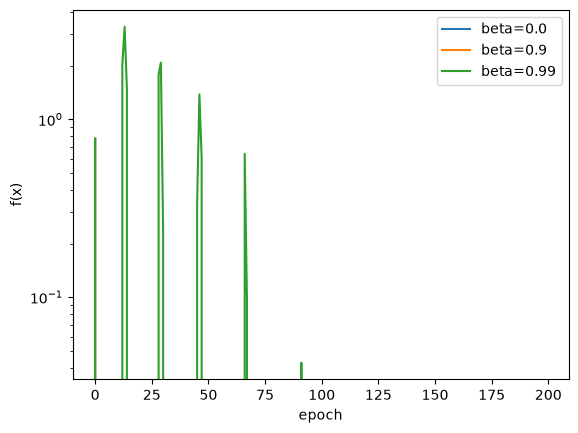

In [14]:
def run(x0, lr, beta, epochs):
    x, v = x0, 0.0
    losses = []
    for _ in range(epochs):
        v = beta * v + grad(x)
        x = x - lr * v
        losses.append(f(x))
    return x, losses

import matplotlib.pyplot as plt

for beta in [0.0, 0.9, 0.99]:
    _, losses = run(2.0, 0.01, beta, 200)
    plt.plot(losses, label=f"beta={beta}")

plt.yscale("log")     # log scale makes the difference obvious
plt.xlabel("epoch"); plt.ylabel("f(x)"); plt.legend(); plt.show()